In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
import sklearn
import pickle
import itertools
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import pandas as pd
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage.morphology import binary_erosion, binary_dilation
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import csv
from functools import reduce
from sklearn.decomposition import PCA
import multiprocessing as mp
from multiprocessing import Pool
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.multiclass import OneVsRestClassifier
import scour.scour
import gzip

In [2]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [3]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
n_clusters=500
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [4]:
# %%time
# total_path = os.path.join(home_path, '10flies_total_dict.pkl')
# print("Loading total dict")
# with open(total_path, 'rb') as file:
#     total_data_dict = pickle.load(file)

# print(total_data_dict.keys())
# print(total_data_dict['250'].keys())

In [5]:
total_path = os.path.join(home_path, '10flies_5sec_event_times_split_dic.pkl')
print("Loading best events dict")
with open(total_path, 'rb') as file:
    total_data_dict = pickle.load(file)

print(total_data_dict.keys())
print(total_data_dict['250'].keys())

Loading best events dict
dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['total', 'inc', 'dec', 'flat'])


In [6]:
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files=os.path.join(cluster_dir,file)
giant_total_labels=np.load(label_files)
print(giant_total_labels.shape)

(4171804,)


In [7]:
label_size=np.zeros(500)
for i,label in enumerate(np.sort(np.unique(giant_total_labels))):
    label_size[i]=np.count_nonzero(np.isin(giant_total_labels,label))
max_size_clus=np.where(label_size==np.max(label_size))[0][0]
print(f'the biggest cluster (and therefore the background) is cluster {max_size_clus}')

the biggest cluster (and therefore the background) is cluster 71


In [8]:
for i,label in enumerate(giant_total_labels):
    if label==max_size_clus:
        giant_total_labels[i]=-100
    elif label>max_size_clus:
        giant_total_labels[i]=label-1

In [9]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)
print(giant_labels_anat.shape)

(314, 146, 91)


In [10]:
#ts is in 10ms units

In [11]:
fly_nums=['226','227','228','234','239','240','241','242','249','250']
fly_num=fly_nums[-1]
dff_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}/dff'
warp_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}/warp'
ch_num=2
for file in os.listdir(dff_path):
    if f'_{ch_num}_' in file:
        file_path=os.path.join(dff_path,file)
for file in os.listdir(warp_path):
    if 'timestamps' in file:
        ts_path=os.path.join(warp_path,file)

In [12]:
%%time
total_path = os.path.join(home_path, 'new_best_5sec_event_times_split_dic.pkl')
print("Loading best events dict")
with open(total_path, 'rb') as file:
    best_data_dict = pickle.load(file)

print(best_data_dict.keys())
print(best_data_dict['250'].keys())

flat_path = os.path.join(home_path, 'new_flat_5sec_event_times_split_dic.pkl')
print("Loading flat events dict")
with open(flat_path, 'rb') as file:
    flat_data_dict = pickle.load(file)

print(flat_data_dict.keys())
print(flat_data_dict['250'].keys())

# old_total = os.path.join(home_path, '10flies_total_dict.pkl')
# print("Loading old dict")
# with open(old_total, 'rb') as file:
#     old_total_dict = pickle.load(file)

# print(old_total_dict.keys())
# print(old_total_dict['250'].keys())

Loading best events dict
dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['inc', 'dec', 'flat', 'non'])
Loading flat events dict
dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['flat'])
CPU times: user 1.39 ms, sys: 1.46 ms, total: 2.85 ms
Wall time: 37.5 ms


In [13]:
print(np.shape(best_data_dict['227']['flat']))
print(np.shape(flat_data_dict['227']['flat']))

(133,)
(25,)


In [14]:
count={'inc':0,'dec':0,'flat':0,'non':0}
for fly in best_data_dict:
    ci=np.shape(best_data_dict[fly]['inc'])[0]
    cd=np.shape(best_data_dict[fly]['dec'])[0]
    cf=np.shape(best_data_dict[fly]['flat'])[0]
    cn=np.shape(best_data_dict[fly]['non'])[0]
    count['inc']+=ci
    count['dec']+=cd
    count['flat']+=cf
    count['non']+=cn
print(f'inc {count["inc"]} dec {count["dec"]} flat {count["flat"]} non {count["non"]}')
min_count=np.min([count['inc'],count['dec'],count['flat'],count['non']])

inc 133 dec 144 flat 522 non 196


In [15]:
for fly in best_data_dict:
    for b in best_data_dict[fly]:
        num_trials=count[b]
#         print(num_trials)
        per=min_count/num_trials
#         print(per)
        num_current=np.shape(best_data_dict[fly][b])[0]
#         print(num_current)
        thirty=int(num_current*per)
        arr=np.random.choice(np.arange(num_current),thirty,replace=False)
        arr = np.sort(np.asarray(arr).astype(int))
        best_data_dict[fly][b]=np.asarray(best_data_dict[fly][b])[arr]

In [16]:
count_new={'inc':0,'dec':0,'flat':0,'non':0}
for fly in best_data_dict:
    ci=np.shape(best_data_dict[fly]['inc'])[0]
    cd=np.shape(best_data_dict[fly]['dec'])[0]
    cf=np.shape(best_data_dict[fly]['flat'])[0]
    cn=np.shape(best_data_dict[fly]['non'])[0]
    count_new['inc']+=ci
    count_new['dec']+=cd
    count_new['flat']+=cf
    count_new['non']+=cn
print(f'inc {count_new["inc"]} dec {count_new["dec"]} flat {count_new["flat"]} non {count_new["non"]}')

inc 133 dec 129 flat 128 non 129


In [17]:
fly_nums=['226','227','228','234','239','240','241','242','249','250']
event_labels={}
for fly in fly_nums:
    event_labels[fly]={}
    trials=np.hstack(list(best_data_dict[fly].values()))
    best_trial_num=np.shape(trials)[0]
#     print(best_trial_num)
    event_labels[fly]['label']=np.full(best_trial_num,str)
    event_labels[fly]['idx']=np.full(best_trial_num,int)
    event_labels[fly]['time']=np.full(best_trial_num,int)
    time=0
    for behave in best_data_dict[fly]:
        for i in range(np.shape(best_data_dict[fly][behave])[0]):
            place=np.where(np.isin(total_data_dict[fly]['total'],best_data_dict[fly][behave][i]))[0][0]
#             print(f'{fly}: {behave}, {place}, {best_data_dict[fly][behave][i]}, {total_data_dict[fly]["total"][place]}')
            event_labels[fly]['label'][time]=behave
            event_labels[fly]['idx'][time]=place
            event_labels[fly]['time'][time]=total_data_dict[fly]['total'][place]
            time+=1
#             print(time)

In [18]:
one=event_labels['226']['idx'].shape[0]
two=event_labels['227']['idx'].shape[0]
print(one)
print(two)
print(one+two)

31
48
79


In [19]:
# test_fly_nums=['226','227','228']#,'234','239']
fly_clust={}
for fly in fly_nums:
    fly_path=os.path.join(home_path,f'{fly}_individual_clusters_new_ch_2_dict.pkl')
    if os.path.exists(fly_path):
        print(f'fly is {fly}')
        with open(fly_path, 'rb') as file:
            fly_ind_dict = pickle.load(file)
            fly_clust[fly]=fly_ind_dict
    else:
        print('not there yet!')


fly is 226
fly is 227
fly is 228
fly is 234
fly is 239
fly is 240
fly is 241
fly is 242
fly is 249
fly is 250


In [20]:
print(np.shape(list(fly_clust['226'][499].keys())))

(197,)


In [23]:
%%time
#preload cluster #s
best_events={}
range_r=np.arange(500)
for cluster in range_r:
    if cluster!=max_size_clus:
        best_events[cluster]={'vals':[],'label':[]}
for fly in fly_clust:
    print(f'fly is {fly}')
    for cluster in fly_clust[fly]:
#         print(f'cluster is {cluster}')
        if cluster!=max_size_clus:
            for i,event in enumerate(event_labels[str(fly)]['idx']):
    #             print(f'event is {event}, and idx is {i}')
#                 print(i)
                try:
                    best_events[cluster]['vals'].append(np.nanmean(fly_clust[fly][cluster][event][-1]))

                    best_events[cluster]['label'].append(event_labels[str(fly)]['label'][i])
                except:
                    continue

fly is 226
fly is 227
fly is 228
fly is 234
fly is 239
fly is 240
fly is 241
fly is 242
fly is 249
fly is 250
CPU times: user 8.44 s, sys: 0 ns, total: 8.44 s
Wall time: 8.44 s


In [24]:
sep_events={}
for key in best_events:
    sep_events[key]={}
    labels=np.asarray(best_events[key]['label'])
    labels_idx=np.where((labels == 'inc') | (labels == 'flat') | (labels == 'dec'))
#     print(np.shape(labels_idx))
    data_labels=np.asarray(best_events[key]['label'])[labels_idx]
    data_vals=np.asarray(best_events[key]['vals'])[labels_idx]
    sep_events[key]['vals']=data_vals
    sep_events[key]['label']=data_labels

In [25]:
print(np.count_nonzero(~np.isnan(sep_events[2]['vals'])))
print(sep_events[499]['vals'].shape)

387
(387,)


In [26]:
total_path = os.path.join(home_path, '10flies_total_dict.pkl')
with open(total_path, 'rb') as file:
    total_data_dict_2 = pickle.load(file)

In [27]:
total_event_times_dic={}
total_trials={'inc':[],'dec':[],'flat':[],'non':[]}
total_idx={}
total_behavior={'total':[],'dec':[],'inc':[],'flat':[],'non':[]}
behave_lst={}
for fly in total_data_dict_2:
    total_event_times_dic[fly]={'inc':[],'dec':[],'flat':[],'non':[]}
    total_idx[fly]={'inc':[],'dec':[],'flat':[],'non':[]}
    fly_behavior=total_data_dict_2[fly]['behavior']
    looms=total_data_dict_2[fly]['event_times']
    behave_lst[fly]={'total':[],'label':[]}
    for i,trial in enumerate(fly_behavior):
    #     print(np.shape(trial))
        pre=np.mean(trial[150:200])
        post=np.mean(trial[250:300])
        total_behavior['total'].append([pre, post])
        behave_lst[fly]['total'].append([pre, post])
        if pre>-0.1 and pre<0.1 and post>-0.1 and post<0.1:
                total_event_times_dic[fly]['flat'].append(looms[i])
                total_trials['flat'].append(fly_behavior[i])
                total_behavior['flat'].append([pre, post])
                total_idx[fly]['flat'].append(i)
                b='flat'
        elif post>np.abs(pre*2):
                total_event_times_dic[fly]['inc'].append(looms[i])
                total_trials['inc'].append(fly_behavior[i])
                total_behavior['inc'].append([pre, post])
                total_idx[fly]['inc'].append(i)
                b='inc'
        elif post<pre/2:
                total_event_times_dic[fly]['dec'].append(looms[i])
                total_trials['dec'].append(fly_behavior[i])
                total_behavior['dec'].append([pre, post])
                total_idx[fly]['dec'].append(i)
                b='dec'
                
        else:
            total_event_times_dic[fly]['non'].append(looms[i])
            total_trials['non'].append(fly_behavior[i])
            total_behavior['non'].append([pre, post])
            total_idx[fly]['non'].append(i)
            b='non'
        behave_lst[fly]['label'].append(b)
    behave_lst[fly]['label']=np.asarray(behave_lst[fly]['label'])
    behave_lst[fly]['total']=np.asarray(behave_lst[fly]['total'])

In [64]:
%%time
total_events_behave={}
for fly in fly_clust:
    print(f'fly is {fly}')
    total_events_behave[fly]={'vals':[],'label':[],'fv':[]}
    for cluster in fly_clust[fly]:
#         print(f'cluster is {cluster}')
        if cluster!=max_size_clus:
            tempv=[]
            templ=[]
            tempf=[]
            for i,event in enumerate(behave_lst[str(fly)]['label']):
                try:
#                 print(f'event is {event}, and idx is {i}, and cluster is {cluster}')
                    tempv.append(fly_clust[fly][cluster][i][-1])
                    templ.append(event)
                    tempf.append(behave_lst[str(fly)]['total'][i])
#                 print(np.shape(tempf))
                except:
                    continue
            total_events_behave[fly]['vals'].append(tempv)
            total_events_behave[fly]['label'].append(templ)
    total_events_behave[fly]['vals']=np.vstack(total_events_behave[fly]['vals'])
    total_events_behave[fly]['label']=np.vstack(total_events_behave[fly]['label'])[0]
    total_events_behave[fly]['fv']=np.vstack(tempf)
#     total_events_behave[fly]['event_num']=np.vstack(total_events_behave[fly]['event_num'])

fly is 226
fly is 227
fly is 228
fly is 234
fly is 239
fly is 240
fly is 241
fly is 242
fly is 249
fly is 250
CPU times: user 1.48 s, sys: 9.94 ms, total: 1.49 s
Wall time: 1.49 s


In [65]:
total_path = os.path.join(home_path, 'new_10flies_5sec_event_times_split_dic.pkl')
print("Loading best events dict")
with open(total_path, 'rb') as file:
    all_flies_data_dict = pickle.load(file)
    print(all_flies_data_dict.keys())

Loading best events dict
dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])


In [66]:
for fly in all_flies_data_dict:
    for b in all_flies_data_dict[fly]:
        bool_sp=~np.isin(all_flies_data_dict[fly][b],best_data_dict[fly][b])
#         print(np.shape(bool_sp))
        all_flies_data_dict[fly][b]=np.asarray(all_flies_data_dict[fly][b])[bool_sp]

In [67]:
count={'inc':0,'dec':0,'flat':0,'non':0}
for fly in best_data_dict:
    ci=np.shape(all_flies_data_dict[fly]['inc'])[0]
    cd=np.shape(all_flies_data_dict[fly]['dec'])[0]
    cf=np.shape(all_flies_data_dict[fly]['flat'])[0]
    cn=np.shape(all_flies_data_dict[fly]['non'])[0]
    count['inc']+=ci
    count['dec']+=cd
    count['flat']+=cf
    count['non']+=cn
print(f'inc {count["inc"]} dec {count["dec"]} flat {count["flat"]} non {count["non"]}')
min_count=np.min([count['inc'],count['dec'],count['flat'],count['non']])

inc 251 dec 567 flat 393 non 323


In [68]:
for fly in all_flies_data_dict:
    for b in all_flies_data_dict[fly]:
        num_trials=count[b]
#         print(num_trials)
        per=min_count/num_trials
#         print(per)
        num_current=np.shape(all_flies_data_dict[fly][b])[0]
#         print(num_current)
        thirty=int(num_current*per)
        arr=np.random.choice(np.arange(num_current),thirty,replace=False)
        arr = np.sort(np.asarray(arr).astype(int))
        all_flies_data_dict[fly][b]=np.asarray(all_flies_data_dict[fly][b])[arr]

In [69]:
fly_nums=['226','227','228','234','239','240','241','242','249','250']
total_event_labels={}
for fly in fly_nums:
    total_event_labels[fly]={}
    trials=np.hstack(list(all_flies_data_dict[fly].values()))
    best_trial_num=np.shape(trials)[0]
#     print(best_trial_num)
    total_event_labels[fly]['label']=np.full(best_trial_num,str)
    total_event_labels[fly]['idx']=np.full(best_trial_num,int)
    total_event_labels[fly]['time']=np.full(best_trial_num,int)
    time=0
    for behave in all_flies_data_dict[fly]:
        for i in range(np.shape(all_flies_data_dict[fly][behave])[0]):
            place=np.where(np.isin(total_data_dict[fly]['total'],all_flies_data_dict[fly][behave][i]))[0][0]
#             print(f'{fly}: {behave}, {place}, {best_data_dict[fly][behave][i]}, {total_data_dict[fly]["total"][place]}')
            total_event_labels[fly]['label'][time]=behave
            total_event_labels[fly]['idx'][time]=place
            total_event_labels[fly]['time'][time]=total_data_dict[fly]['total'][place]
            time+=1

In [70]:
%%time
#preload cluster #s
total_events={}
range_r=np.arange(500)
for cluster in range_r:
    if cluster!=max_size_clus:
        total_events[cluster]={'vals':[],'label':[]}
for fly in fly_clust:
    print(f'fly is {fly}')
    for cluster in fly_clust[fly]:
#         print(f'cluster is {cluster}')
        if cluster!=max_size_clus:
            for i,event in enumerate(total_event_labels[str(fly)]['idx']):
    #             print(f'event is {event}, and idx is {i}')
                total_events[cluster]['vals'].append(np.nanmean(fly_clust[fly][cluster][event][-1]))
                total_events[cluster]['label'].append(total_event_labels[str(fly)]['label'][i])

fly is 226
fly is 227
fly is 228
fly is 234
fly is 239
fly is 240
fly is 241
fly is 242
fly is 249
fly is 250
CPU times: user 15.9 s, sys: 0 ns, total: 15.9 s
Wall time: 15.9 s


In [71]:
total_sep_events={}
for key in total_events:
    total_sep_events[key]={}
    labels=np.asarray(total_events[key]['label'])
    labels_idx=np.where((labels == 'inc') | (labels == 'flat') | (labels == 'dec'))
#     print(np.shape(labels_idx))
    data_labels=np.asarray(total_events[key]['label'])[labels_idx]
    data_vals=np.asarray(total_events[key]['vals'])[labels_idx]
    total_sep_events[key]['vals']=data_vals
    total_sep_events[key]['label']=data_labels

In [72]:
dict_to_look=sep_events
# First, create your full X and y
X = []
y = dict_to_look[0]['label']  # labels should be same across all clusters

for cluster in range(500):
    if cluster!=max_size_clus:
        X.append(dict_to_look[cluster]['vals'])

X = np.vstack(X).T  # Transpose to get (n_trials, n_clusters)
print(np.shape(X))
y = np.array(y)
print(np.shape(y))

(387, 499)
(387,)


In [73]:
dict_to_look=total_sep_events
# First, create your full X and y
total_X = []
total_y = dict_to_look[0]['label']  # labels should be same across all clusters

for cluster in range(500):
    if cluster!=max_size_clus:
        total_X.append(dict_to_look[cluster]['vals'])

total_X = np.vstack(total_X).T  # Transpose to get (n_trials, n_clusters)
print(np.shape(total_X))
total_y = np.array(total_y)
print(np.shape(total_y))

(743, 499)
(743,)


In [74]:
to_plot_inc=[]
to_plot_dec=[]
to_plot_flat=[]
for clus in total_events:
    for i, lab in enumerate(total_events[clus]['label']):
        if lab=='inc':
            to_plot_inc.append(total_events[clus]['vals'][i])
        elif lab=='dec':
            to_plot_dec.append(total_events[clus]['vals'][i])
        elif lab=='flat':
            to_plot_flat.append(total_events[clus]['vals'][i])

to_plot_inc=np.vstack(to_plot_inc)
to_plot_dec=np.vstack(to_plot_dec)
to_plot_flat=np.vstack(to_plot_flat)

In [75]:
np.shape(to_plot_flat)

(122255, 1)

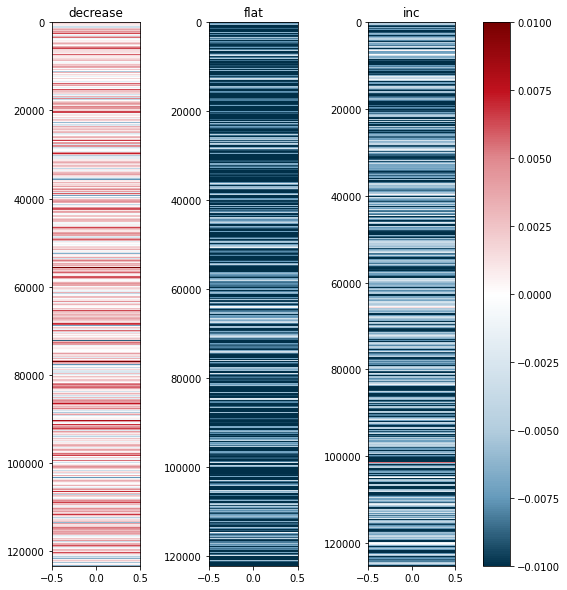

In [76]:
vmin=-0.01
vmax=0.01
ax_ap=0.00005
fig,ax=plt.subplots(1,3,figsize=(10,10))
im1=ax[0].imshow(np.asarray(to_plot_dec), cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[0].set_title('decrease')
ax[0].set_aspect(ax_ap)
ax[1].imshow(np.asarray(to_plot_flat), cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[1].set_aspect(ax_ap)
ax[1].set_title('flat')
ax[2].imshow(np.asarray(to_plot_inc), cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[2].set_aspect(ax_ap)
ax[2].set_title('inc')
fig.colorbar(im1,ax=[ax[0],ax[1],ax[2]])

In [77]:
# %%time
# null_scores_total=[]
# train_acc_total=[]
# test_acc_total=[]
# y_predict_total=[]
# y_idxs=[]
# total_scores=[]
# total_null_scores=[]
# total_y_idxs=[]
# total_y_predict=[]
# top_100=[]
# top_importances=[]
# predictions=[]
# behave=[]
# num_permutations=1000
# for i in range(num_permutations):
#     train_indices, test_indices = train_test_split(
#     np.arange(len(y)), 
#     test_size=0.2, 
#     random_state=i, 
#     stratify=y
#     )
#     # 1. Basic Random Forest
# #     rf = RandomForestClassifier(
# #         n_estimators=200,      # number of trees
# #         max_depth=6,          # max depth of each tree (prevents overfitting)
# #         min_samples_split=10,   # minimum samples to split a node
# #         min_samples_leaf=2,    # minimum samples in leaf
# #         random_state=i,
# #         n_jobs=-1              # use all CPU cores
# #     )

#     rf = RandomForestClassifier(
#         n_estimators=200,      # number of trees
#         max_depth=6,          # max depth of each tree (prevents overfitting)
#         min_samples_split=5,   # minimum samples to split a node
#         min_samples_leaf=1,    # minimum samples in leaf
#         random_state=i,
#         n_jobs=-1              # use all CPU cores
#     )
#     # Fit model
#     rf.fit(X[train_indices], y[train_indices])
    
    
    
    
#     # Evaluate
#     train_acc = rf.score(X[train_indices], y[train_indices])
#     train_acc_total.append(train_acc)
#     test_acc = rf.score(X[test_indices], y[test_indices])
#     test_acc_total.append(test_acc)
    
#     #test null
#     num_lab = len(y[test_indices]) 
# #     print(num_lab)
#     y_null=np.random.choice(list(rf.classes_), size=num_lab)
#     null_acc = rf.score(X[test_indices], y_null)
#     null_scores_total.append(null_acc)
    
#     #pred y
#     y_pred = rf.predict(X[test_indices])
#     y_predict_total.append(y_pred)
#     y_idxs.append(y[test_indices])
    
#     #test total
#     test_total_acc = rf.score(total_X, total_y)
#     total_scores.append(test_total_acc)
    
#     #test null total
#     num_lab_total = len(total_y) 
# #     print(num_lab_total)
#     y_total_null=np.random.choice(list(rf.classes_), size=num_lab_total)
#     null_acc = rf.score(total_X, y_total_null)
#     total_null_scores.append(null_acc)
    
#     #pred y
#     y_pred_total = rf.predict(total_X)
#     total_y_predict.append(y_pred_total)
#     total_y_idxs.append(total_y)
    
    
#     top_100_idx=np.argsort(rf.feature_importances_)[::-1][:100]
#     top_100.append(top_100_idx)
#     top_importances.append(rf.feature_importances_[top_100_idx])
#     for fly in total_events_behave:
        
#         bool_ar=total_events_behave[fly]['label']!='non'
#         pred_X=total_events_behave[fly]['vals'][:,bool_ar]
#         fly_predict=rf.predict(pred_X.T)
#         predictions.append(fly_predict)
#         behave.append(total_events_behave[fly]['fv'][bool_ar])
    
# #     print(predictions.shape,behave.shape)
# null_acc_final=np.mean(null_scores_total)
# train_acc_final=np.mean(train_acc_total)
# test_acc_final=np.mean(test_acc_total)
# # predictions=np.hstack(predictions)
# # behave=np.vstack(behave)
# # y_predict_final=np.mean(y_predict_total)

# print(f"Random Forest Performance:")
# print(f"Train accuracy: {train_acc_final:.3f}, std: {np.std(train_acc_total)}")
# print(f"Test accuracy: {test_acc_final:.3f}, std: {np.std(test_acc_total)}")
# print(f"Null accuracy: {null_acc_final:.3f}, std: {np.std(null_scores_total)}")


Random Forest Performance:
Train accuracy: 0.993, std: 0.0037344146933173095
Test accuracy: 0.633, std: 0.04869452709596098
Null accuracy: 0.330, std: 0.05048352658322083
CPU times: user 20min 29s, sys: 2min 27s, total: 22min 56s
Wall time: 38min 10s


In [78]:
# model_set={'null_scores':null_scores_total,
#            'train_acc':train_acc_total,
#            'test_acc':test_acc_total,
#            'y_predict':y_predict_total,
#            'y_idx':y_idxs,
#            'top_100':top_100,
#            'top_import':top_importances,
#            'pred':predictions,
#            'behave':behave, 
#            'total_null':total_null_scores,
#            'total_y':total_y_idxs,
#            'total_y_predict':total_y_predict,
#            'total_scores':total_scores,
#            'model': rf
           
#           }

In [79]:
file_path=os.path.join(cluster_dir, 'model_set_new.pkl')
# with open(file_path, 'wb') as file:
#         pickle.dump(model_set, file)
with open(file_path, 'rb') as file:
    model_set = pickle.load(file)

In [80]:
val, count=np.unique(model_set['top_100'], return_counts=True)

In [81]:
count.shape

(486,)

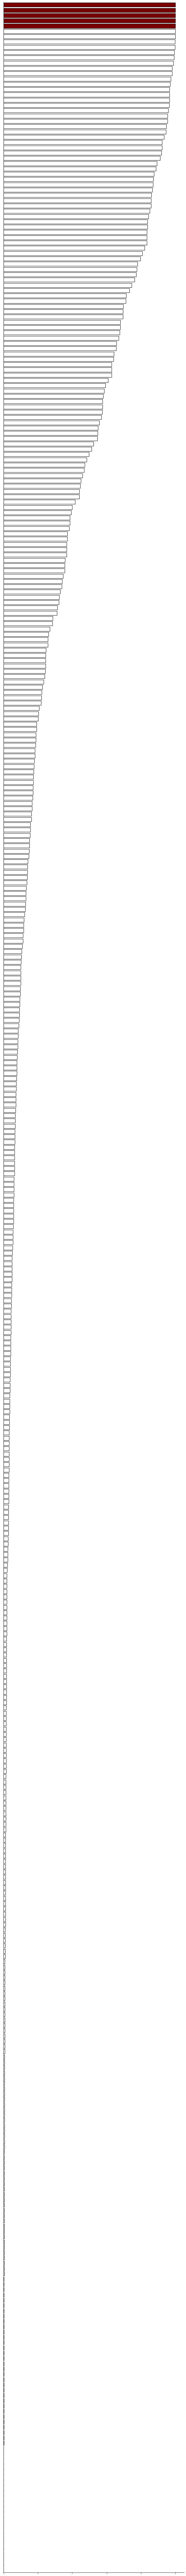

In [82]:
top_num1=5
o=np.argsort(count)[::-1]
amt=count[o].shape[0]
fig_height = max(8, amt * 0.3) 
fig,ax=plt.subplots(figsize=(10,fig_height))
positions=np.arange(len(count))
color_bar=np.full(amt,'#FFFFFF')
color_bar[:top_num1]='#780000'
ax.barh(positions,count[o],color=color_bar,edgecolor='k');
# ax.set_yticks(positions);
# ax.set_yticklabels(val[o]);
ax.set_yticks([]);
ax.set_xticklabels([])
fig.gca().invert_yaxis();
ax.set_ylim(amt - 0.5, -0.5);
ax.tick_params(axis='y',labelsize=20) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'model_counts.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


In [83]:
df=pd.DataFrame({ 'train':model_set['train_acc'],'test':model_set['test_acc'],'null':model_set['null_scores'],'total':np.asarray(model_set['total_scores']),'total null':np.asarray(model_set['total_null']) })

In [84]:
print(np.mean(model_set['train_acc']))
print(np.mean(model_set['test_acc']))
print(np.mean(model_set['null_scores']))
print(np.mean(model_set['total_scores']))
print(np.mean(model_set['total_null']))

0.9928608414239484
0.6332179487179487
0.32974358974358975
0.49278734858681017
0.3332449528936743


In [85]:
TT1 = scipy.stats.ttest_ind(np.asarray(model_set['train_acc']), np.asarray(model_set['test_acc']))
TT2 = scipy.stats.ttest_ind(model_set['null_scores'], model_set['test_acc'])
TT3 = scipy.stats.ttest_ind(model_set['null_scores'], model_set['train_acc'])
TT4 = scipy.stats.ttest_ind(model_set['null_scores'], model_set['total_scores'])
TT5 = scipy.stats.ttest_ind(model_set['total_null'], model_set['total_scores'])

In [86]:
print(TT1)
print(TT2)
print(TT3)
print(TT4)
print(TT5)

Ttest_indResult(statistic=232.75588640934726, pvalue=0.0)
Ttest_indResult(statistic=-136.75194748599097, pvalue=0.0)
Ttest_indResult(statistic=-414.0362780464294, pvalue=0.0)
Ttest_indResult(statistic=-100.48601669335999, pvalue=0.0)
Ttest_indResult(statistic=-263.34710843574913, pvalue=0.0)


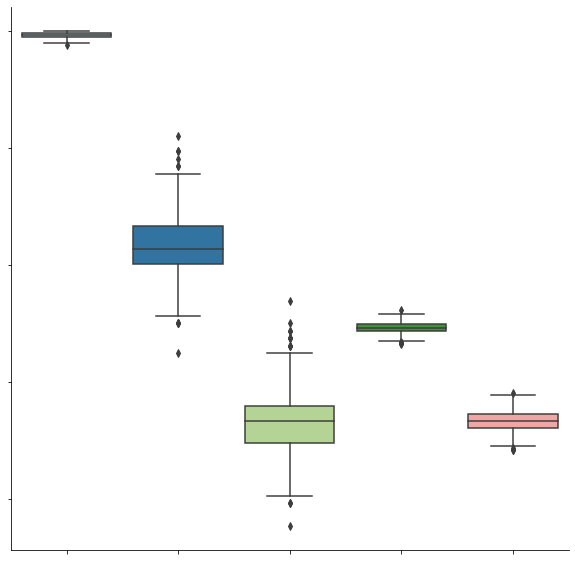

In [87]:
fig,ax=plt.subplots(figsize=(10,10))
sns.boxplot(data=df,ax=ax, palette='Paired')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels([])
ax.set_yticklabels([])
# plt.text(0.5, max(df['null_scores'])*1.05, '****', 
#          ha='center', fontsize=20)
# ax.set_ylim(0,1)
# plt.savefig(os.path.join(save_dir,'model_accuracyscores.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'model_accuracyscores.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
plt.show()

In [88]:
y_predict_final=np.hstack(model_set['y_predict'])
y_idxs_final=np.hstack(model_set['y_idx'])

In [89]:
from sklearn.metrics import classification_report, confusion_matrix

# y_pred = rf.predict(X[test_indices])
print("\nTest Set Classification Report:")
print(classification_report(y_predict_final, y_idxs_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_predict_final, y_idxs_final))


Test Set Classification Report:
              precision    recall  f1-score   support

         dec       0.77      0.69      0.73     28939
        flat       0.53      0.54      0.54     24823
         inc       0.59      0.66      0.63     24238

    accuracy                           0.63     78000
   macro avg       0.63      0.63      0.63     78000
weighted avg       0.64      0.63      0.64     78000


Confusion Matrix:
[[20025  4692  4222]
 [ 4715 13348  6760]
 [ 1260  6960 16018]]


In [90]:
full_pred=np.hstack(model_set['pred'])
full_behave=np.vstack(model_set['behave'])

In [91]:
behavior_colors={
    'inc': '#FC00B9',
    'dec': '#17D4DE',
    'flat': '#000000',
    'non': '#727272',
    'un':'orange'
}

In [92]:
scatter_colors=[]
for event in full_pred:
    scatter_colors.append(behavior_colors[event])
scatter_colors=np.asarray(scatter_colors)

In [93]:
# predictions_without=predictions[~np.isin(np.arange(np.shape(predictions)[0]),train_indices)]
# behave_without=behave[~np.isin(np.arange(np.shape(behave)[0]),train_indices)]
# color_without=scatter_colors[~np.isin(np.arange(np.shape(scatter_colors)[0]),train_indices)]

In [94]:
full_behave.shape

(1598000, 2)

In [95]:
total_events_behave['226']['fv'].shape

(197, 2)

In [96]:
uc_events=[]
for fly in total_events_behave:
    bool_lab=total_events_behave[fly]['label']=='non'
    vels=total_events_behave[fly]['fv'][bool_lab]
    uc_events.append(vels)
uc_events=np.vstack(uc_events)
print(uc_events.shape)

(372, 2)


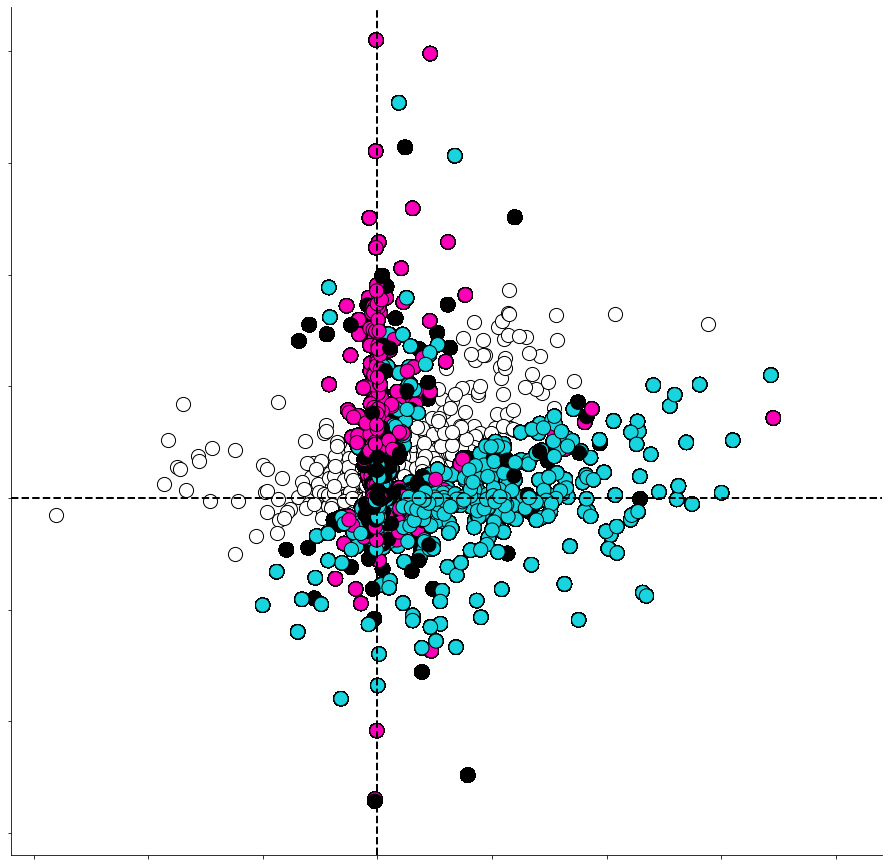

In [97]:
fig = plt.figure(figsize=(20, 20))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                      hspace=0.05, wspace=0.05)
ax_main = fig.add_subplot(gs[1, 0])
# plt.scatter(total_pre, total_post);
behavior_set=full_behave
pred_set=full_pred
ax_main.scatter(np.asarray(uc_events)[:,0], np.asarray(uc_events)[:,1], s=200,color='w',edgecolor='k',rasterized=True);    
ax_main.scatter(np.asarray(behavior_set)[:,0], np.asarray(behavior_set)[:,1], s=200,color=scatter_colors,edgecolor='k',rasterized=True);
        
plt.axvline(0,color='k',linestyle='--',lw=2);
plt.axhline(0,color='k',linestyle='--',lw=2);
# plt.legend();
# ax_main.set_xlabel('Avg velocity 50ms before stim');
# ax_main.set_ylabel('Avg velocity 50ms before end of stim');
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)
ax_main.set_xlim((-8,11))
ax_main.set_ylim((-8,11))
# ax_main.tick_params(axis='y',labelsize=20)
# ax_main.tick_params(axis='x',labelsize=20)
ax_main.set_xticklabels([])
ax_main.set_yticklabels([])
# order=['flat','inc','dec'][::-1]
# ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
# for b in order:
#     x=np.asarray(behavior_set)[:,0][pred_set==b]
#     ax_top.hist(x, bins=40, color=behavior_colors[b], alpha=0.7,rasterized=True, density=True)
# ax_top.tick_params(labelbottom=False)
# # ax_top.set_yticks([])
# # ax_top.set_xticks([])
# # ax_top.set_ylabel('De')
# ax_top.spines['top'].set_visible(False)
# ax_top.spines['right'].set_visible(False)
# ax_top.spines['left'].set_visible(False)
# ax_top.spines['bottom'].set_visible(False)



# ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
# for b in order:
#     y=np.asarray(behavior_set)[:,1][pred_set==b]
#     ax_right.hist(y, bins=40, color=behavior_colors[b], alpha=0.7, orientation='horizontal', rasterized=True,density=True)
# ax_right.tick_params(labelleft=False)
# # ax_right.set_yticks([])
# # ax_right.set_xticks([])
# # ax_right.set_xlabel('Count')
# ax_right.spines['top'].set_visible(False)
# ax_right.spines['right'].set_visible(False)
# ax_right.spines['bottom'].set_visible(False)
# ax_right.spines['left'].set_visible(False)
# plt.rcParams['path.simplify'] = True
# plt.rcParams['path.simplify_threshold'] = 1.0
# plt.rcParams['svg.fonttype'] = 'none'
# plt.savefig(os.path.join(save_dir,'model_scatter.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,'model_scatter.png'), dpi=300, bbox_inches='tight', format="png", transparent=True)
# svgz_path = os.path.join(save_dir, 'model_scatter.svgz')
# with gzip.open(svgz_path, 'wb', compresslevel=9) as f:
#     plt.savefig(f, dpi=300, bbox_inches='tight', format='svg', transparent=True)
plt.show()


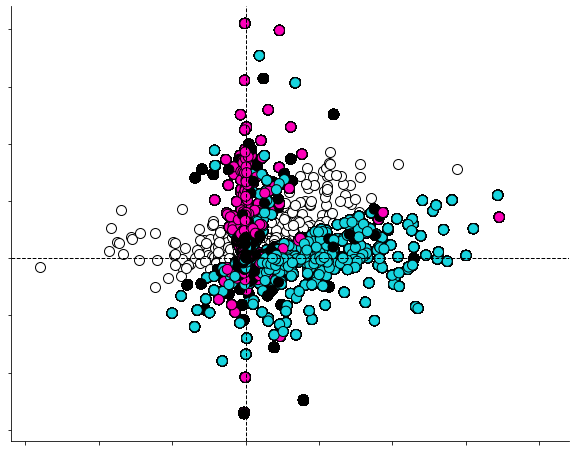

In [98]:
fig,ax=plt.subplots(figsize=(10, 8))
# plt.scatter(total_pre, total_post);
behavior_set=full_behave
pred_set=full_pred

ax.scatter(np.asarray(uc_events)[:,0], np.asarray(uc_events)[:,1], s=100,color='w',edgecolor='k');    
ax.scatter(np.asarray(behavior_set)[:,0], np.asarray(behavior_set)[:,1], s=100,color=scatter_colors,edgecolor='k');
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
ax.set_xticklabels([]);
ax.set_yticklabels([]);
ax.set_xlim(-8,11)
ax.set_ylim(-8,11)
plt.axvline(0,color='k',linestyle='--',lw=1);
plt.axhline(0,color='k',linestyle='--',lw=1);
# plt.savefig(os.path.join(save_dir,'model_scatter.png'), dpi=300, bbox_inches='tight', format="png", transparent=True)

In [99]:
np.shape(full_behave)

(1598000, 2)

Text(0, 0.5, '')

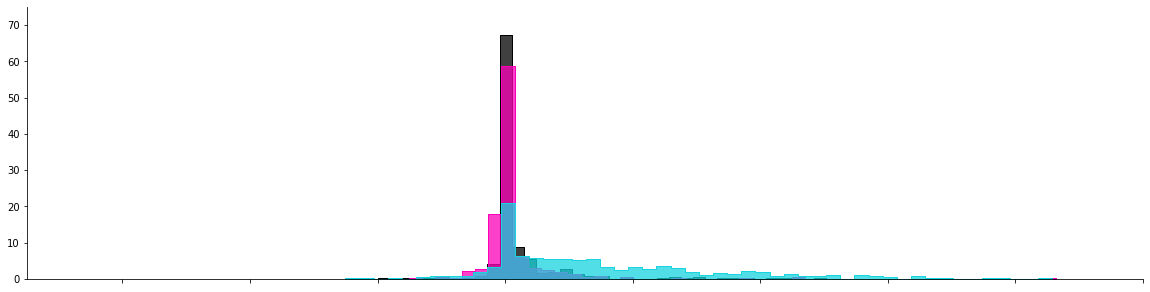

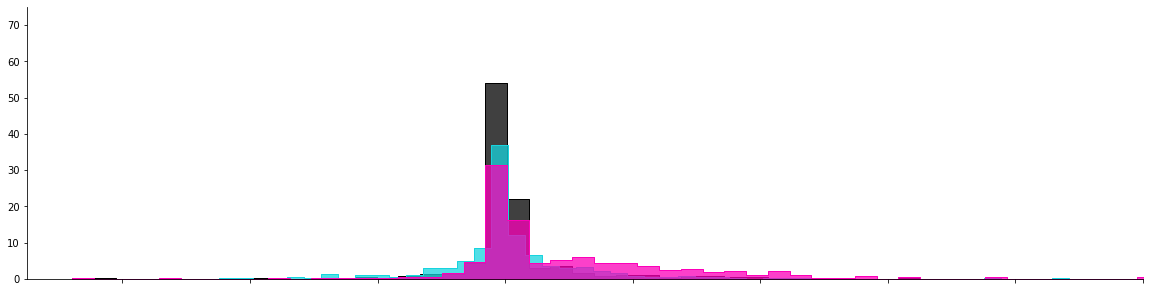

In [100]:
fig,ax = plt.subplots(figsize=(20, 5))
order=['dec','inc','flat'][::-1]
behavior_set=full_behave
pred_set=full_pred
for b in order:
    x=np.asarray(behavior_set)[:,0][pred_set==b]
    sns.histplot(x, bins=50, color=behavior_colors[b], element="step",
    stat="percent", common_norm=False)
ax.set_xlim(-7.5,10)
ax.set_ylim(0,75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.set_ylim(0,3)
# ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_ylabel('')
# plt.savefig(os.path.join(save_dir,f'model_hist_before.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

order=['inc','dec','flat'][::-1]
fig,ax = plt.subplots(figsize=(20, 5))
for b in order:
    y=np.asarray(behavior_set)[:,1][pred_set==b]
    sns.histplot(y, bins=50, color=behavior_colors[b], element="step",
    stat="percent", common_norm=False)
ax.set_xlim(-7.5,10)
ax.set_ylim(0,75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.set_ylim(0,3)
# ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_ylabel('')
# plt.savefig(os.path.join(save_dir,f'model_hist_during.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


In [101]:
# def make_cdf(X, x, comps):
#     # estimate probability density function (pdf)
#     model = GaussianMixture(n_components=comps)
#     model.fit(X)
#     logprob = model.score_samples(x.reshape(-1, 1))
#     pdf = np.exp(logprob)
#     # derive cumulative distribution function (cdf)
#     cdf = np.cumsum(pdf)
#     # scale as a probability distribution
#     cdf = cdf / np.max(cdf)
#     return cdf,pdf

In [102]:
# n_bins=40
# behavior_set=full_behave
# pred_set=full_pred
# order=['flat','inc','dec'][::-1]
# cdfs={'flat':{},'inc':{},'dec':{}}
# for b in order:
#     x=np.asarray(behavior_set)[:,0][pred_set==b].reshape(-1, 1)
#     y=np.asarray(behavior_set)[:,1][pred_set==b].reshape(-1, 1)
#     valb, edgesb=np.histogram(x)
#     vald, edgesd=np.histogram(y)
#     all_edges=[edgesb.max(), edgesb.min(), edgesd.max(), edgesd.min()]
#     total_max=np.max(all_edges)
#     total_min=np.min(all_edges)
#     j = np.linspace(total_min, total_max, 1000)
#     cdfb, pdfb=make_cdf(x, j, 5)
#     cdfd, pdfd=make_cdf(y, j, 5)
#     cdfs[b]['p']=cdfb
#     cdfs[b]['d']=cdfd
# #     x=np.asarray(behavior_set)[:,0][pred_set==b]
# #     hist_b, edges_b=np.histogram(x, bins=int(n_bins/2), density=True)
# #     y=np.asarray(behavior_set)[:,1][pred_set==b]
# #     hist_d, edges_d=np.histogram(y, bins=int(n_bins/2), density=True)
    
# #     b=norm.cdf(hist_b, edges_b[:-1])
# #     cdfs
# #     d=norm.cdf(hist_d, edges_d[:-1])

In [103]:
# # plot data and pdf  
# fig,ax = plt.subplots(figsize=(20, 5))
# for b in order:
#     ax.plot(j, cdfs[b]['p'], color=behavior_colors[b]);
# ax.set_xlim(-7.5,10);
# ax.spines['top'].set_visible(False);
# ax.spines['right'].set_visible(False);
# # ax.set_yticklabels([]);
# # ax.set_xticklabels([]);
# # plt.savefig(os.path.join(save_dir,f'model_cdf_before.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


# fig,ax = plt.subplots(figsize=(20, 5))
# for b in order:
#     ax.plot(j, cdfs[b]['d'], color=behavior_colors[b]);
# ax.set_xlim(-7.5,10);
# ax.spines['top'].set_visible(False);
# ax.spines['right'].set_visible(False);
# # ax.set_yticklabels([]);
# # ax.set_xticklabels([]);
# # plt.savefig(os.path.join(save_dir,f'model_cdf_during.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


In [104]:
# KS1 = scipy.stats.ks_2samp(cdfs['inc']['p'], cdfs['flat']['p'])
# KS2 = scipy.stats.ks_2samp(cdfs['inc']['p'], cdfs['dec']['p'])
# KS3 = scipy.stats.ks_2samp(cdfs['dec']['p'], cdfs['flat']['p'])

In [105]:
# print(KS1)
# print(KS2)
# print(KS3)

In [106]:
# KS1 = scipy.stats.ks_2samp(cdfs['inc']['d'], cdfs['flat']['d'])
# KS2 = scipy.stats.ks_2samp(cdfs['inc']['d'], cdfs['dec']['d'])
# KS3 = scipy.stats.ks_2samp(cdfs['dec']['d'], cdfs['flat']['d'])

In [107]:
# print(KS1)
# print(KS2)
# print(KS3)

In [108]:
cmaps_beahve={
    'inc': matplotlib.colors.LinearSegmentedColormap.from_list('custom', ['w','#FC00B9']),
    'dec': matplotlib.colors.LinearSegmentedColormap.from_list('custom', ['w','#17D4DE']),
    'flat': matplotlib.colors.LinearSegmentedColormap.from_list('custom', ['w','#000000']),
    'non': matplotlib.colors.LinearSegmentedColormap.from_list('custom', ['w','#727272']),
}

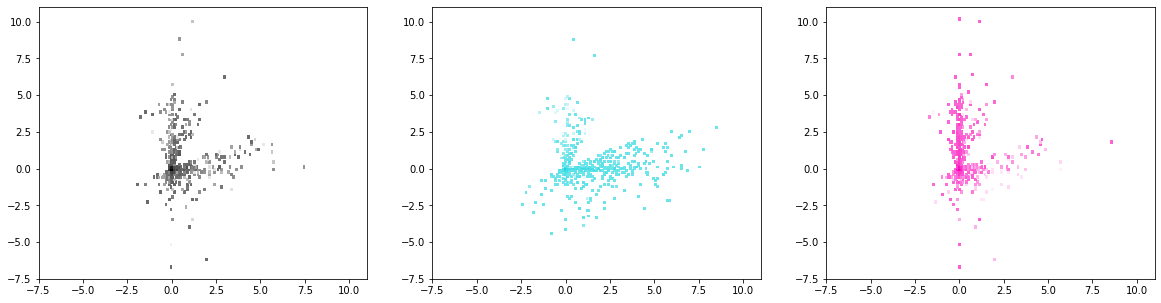

In [109]:
fig,ax = plt.subplots(1,3,figsize=(20, 5))
order=['inc','dec','flat'][::-1]
for i,b in enumerate(order):
    y=np.asarray(behavior_set)[:,1][pred_set==b]
    x=np.asarray(behavior_set)[:,0][pred_set==b]
    ax[i].hist2d(x, y,bins=100,cmap=cmaps_beahve[b],norm=colors.LogNorm())
    ax[i].set_ylim(-7.5,11)
    ax[i].set_xlim(-7.5,11)

In [110]:
print(f'inc: {(np.count_nonzero(full_pred=="inc")/np.shape(full_pred)[0])*100}')
print(f'dec: {(np.count_nonzero(full_pred=="dec")/np.shape(full_pred)[0])*100}')
print(f'flat: {(np.count_nonzero(full_pred=="flat")/np.shape(full_pred)[0])*100}')
pie={'inc':np.count_nonzero(full_pred=="inc"),'dec':np.count_nonzero(full_pred=="dec"),'flat':np.count_nonzero(full_pred=="flat")}

inc: 28.853254067584484
dec: 35.31858573216521
flat: 35.828160200250316


In [111]:
def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.1f}%"


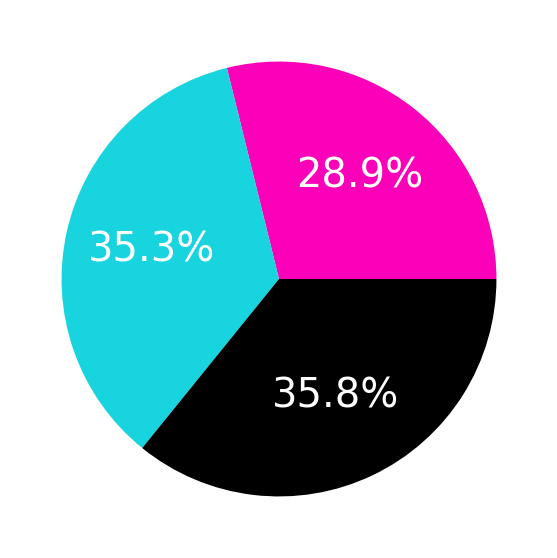

In [112]:
pie_col=['#FC00B9','#17D4DE','#000000']
fig, ax = plt.subplots(figsize=(10,10))
ax.pie(x=list(pie.values()), colors=pie_col,autopct=lambda pct: func(pct, list(pie.values())),textprops=dict(color="w",size=40));
# plt.savefig(os.path.join(save_dir,'model_pie.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'model_pie.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)



In [113]:
ids,counts=np.unique(model_set['top_100'], return_counts=True)
top_ids=ids[np.argsort(counts)[::-1]][:100]
top_counts=counts[np.argsort(counts)[::-1]][:100]

In [114]:
np.asarray(model_set['top_import']).shape

(1000, 100)

In [115]:
top_100=np.asarray(model_set['top_100'])
top_import=np.asarray(model_set['top_import'])
new_importances={}
for i in top_ids:
    new_importances[i]=[]
for i in top_ids:
#     print(i)
    for j,x in enumerate(top_import):
#         print(x)
        importance_vals=x
        val=importance_vals[np.isin(top_100[j,:],i)]
        new_importances[i].append(val)
    new_importances[i]=np.hstack(new_importances[i])

In [116]:
top_importances_final=[]
for ids in new_importances:
    top_importances_final.append(np.mean(new_importances[ids]))
top_importances_final=np.asarray(top_importances_final)

In [117]:
order=np.argsort(top_importances_final)[::-1]
ids=top_ids[order]
count=top_counts[order]
importance=top_importances_final[order]

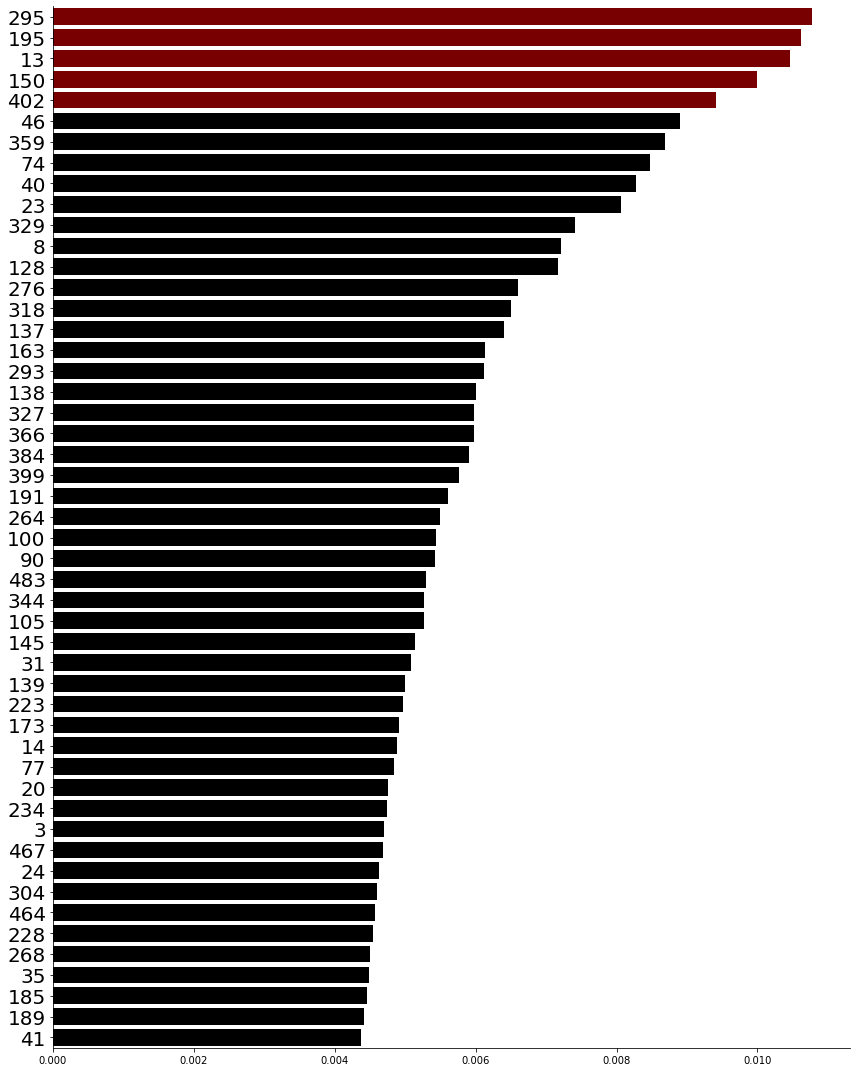

In [118]:
# Plot feature importances
amt=50
top_num1=5
top_num2=10
fig_height = max(8, amt * 0.3) 
fig,ax=plt.subplots(figsize=(12, fig_height))
positions = np.arange(amt)
color_bar=np.full(amt,'#000000')
color_bar[:top_num1]='#780000'
# color_bar[top_num1:top_num2]='#003049'
# top = importance_df.head(amt)
ax.barh(positions,importance[:amt],color=color_bar)
ax.set_yticks(positions)
ax.set_yticklabels(ids[:amt])
# ax.set_xticklabels([])
ax.tick_params(axis='y',labelsize=20) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.xlabel('Importance')
# plt.ylabel('Cluster ID')
# plt.title(f'Top {amt} Most Important Clusters')
fig.gca().invert_yaxis()
ax.set_ylim(amt - 0.5, -0.5)

# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_bar.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_bar.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
plt.tight_layout()
plt.show()

In [119]:
def create_dark_to_color_cmap(color):
    """Create colormap from black to specified color"""
    return matplotlib.colors.LinearSegmentedColormap.from_list('custom', ['#FFADAD',color,color]) # '#70CDFF'

In [120]:
load_file = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/20210817_luke_mean_highres.nii"
anat_high_res = np.asarray(nib.load(load_file).get_fdata().squeeze(), dtype='float32')
anat_high_res.shape
anat_uint=anat_high_res.astype('uint8')

In [121]:
atlas_path = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/jfrc_2018_rois_improve_reorient_transformed_nearest_neighbor.nii"
atlas = np.asarray(nib.load(atlas_path).get_fdata().squeeze(), dtype='float32')
atlas = ants.from_numpy(atlas)
atlas.set_spacing((.76,.76,.76))
#atlas = ants.resample_image(atlas,(2,2,2),use_voxels=False)
atlas = ants.resample_image(atlas,(.5,.5,.5),use_voxels=False)
print(atlas.shape)
atlas = atlas.numpy()
atlas_int = atlas.astype('uint8')


(1256, 584, 363)


In [122]:
nx,ny,nz=atlas.shape
ox,oy,oz=giant_labels_anat.shape
# scale_factors = (nx/ox, ny/oy, nz/oz)
scale_factors = (ox/nx, oy/ny, oz/nz)
# Resample using zoom with cubic interpolation (order=3)
anat_lowres = zoom(anat_high_res, scale_factors, order=3)
atlas_lowres = zoom(atlas_int, scale_factors, order=3)

In [123]:
print(anat_lowres.shape)
# atlas_int = anat_lowres.astype('uint8')

(314, 146, 91)


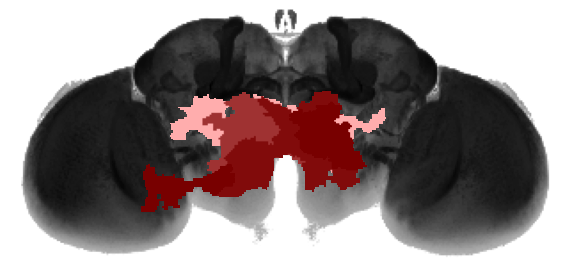

In [129]:
amt=5
# print(np.shape(cluster_importances[b]))
fig,ax=plt.subplots(figsize=(10,10))
plt.imshow(np.max(anat_lowres, axis=-1).T,cmap='gray_r');
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,ids[:amt]),giant_labels_anat,np.nan)
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=create_dark_to_color_cmap('#780000'))
ax.axis('off');
# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_loc.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_loc.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


In [119]:
roi_atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [120]:
def explode_plot(brain,vmax,explosion_rois,roi_masks,roi_contours,tp=None,cmap='seismic'):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    if tp==None:
        data_to_plot = brain[:,:,::-1]
    else:
        data_to_plot = brain[tp][:,:,::-1]
    vmax =vmax #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap=cmap, diverging=False)#'hot')
    return explosion_map

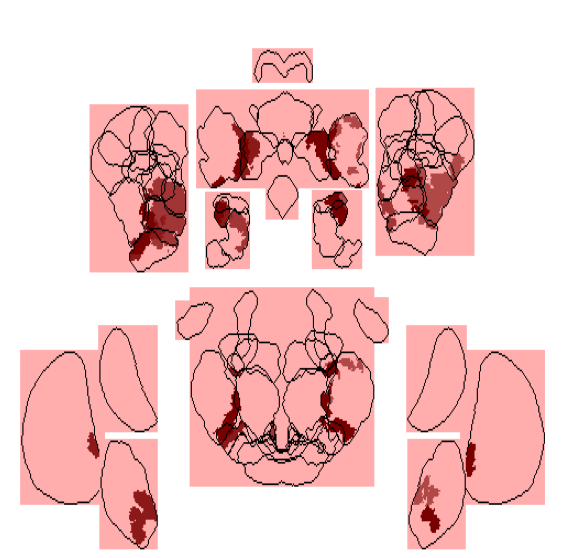

In [121]:
ax_as=1.5
vmax=np.nanmax(labels_anat_sub_total)
fig,axs=plt.subplots(figsize=(10,10))
temp=explode_plot(np.nan_to_num(labels_anat_sub_total),vmax,explosion_rois,roi_masks,roi_contours,cmap=create_dark_to_color_cmap('#780000'))
brain=axs.imshow(temp[170:,:]) #this was made with cmap=hot
axs.axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
axs.set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'top{amt}_explosion.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'top{amt}_explosion.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


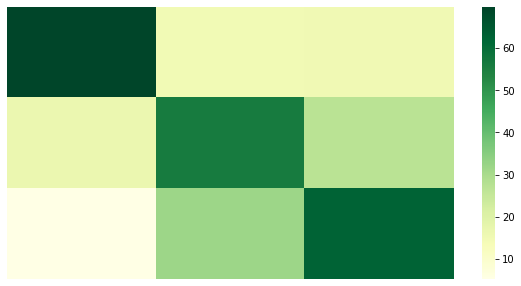

In [122]:
be=['dec','flat','inc']
cm = confusion_matrix(y_predict_final, y_idxs_final)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cm_percent, ax=ax, cmap='YlGn');
ax.xaxis.set_ticks([]);
ax.yaxis.set_ticks([]);
# _ = ax.set_title(
#     f"Confusion Matrix for {rf.__class__.__name__}"
# )

# plt.savefig(os.path.join(save_dir,f'confusion_matrix_{rf.__class__.__name__}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'onfusion_matrix_randomforest.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


In [123]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [124]:
event1='new_best_5sec'
# event2='best'
n_clusters=500
label_files=[]
cluster_files=[]
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files.append(file)
    elif f'_{n_clusters}_' in file and 'clusters' in file and event1 in file:
        cluster_files.append(file)

## Load supervox

In [ ]:
cluster_files

In [ ]:
%%time
best_cluster_path_5sec=os.path.join(cluster_dir,cluster_files[0])
# best_cluster_path=os.path.join(cluster_dir,cluster_files[1])
print(best_cluster_path_5sec)
with open(best_cluster_path_5sec, 'rb') as file:
    five_sec = pickle.load(file)
    print(five_sec.keys())

# with open(best_cluster_path, 'rb') as file:
#     best = pickle.load(file)
#     print(best.keys())
    

In [ ]:
label_files

In [ ]:
%%time
best_label_path=os.path.join(cluster_dir,label_files[0])
print(best_label_path)
giant_total_labels=np.load(best_label_path)
print(giant_total_labels.shape)

In [ ]:
giant_total_anat=giant_total_labels.reshape(314,146,91)


In [ ]:
rainbow_color=np.asarray(['#FFFFFF','#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#6d0d25']) #,  '#6d0d25'
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [ ]:
giant_total_anat.shape

In [ ]:
fixed = brainsss.load_fda_meanbrain()
behaviors=list(five_sec.keys())

In [ ]:
# ax_ap=0.1
# superclust_dict=best
# fig,axs=plt.subplots(1,3,figsize=(10,10))
# axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
# axs[0].set_aspect(ax_ap)
# axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
# axs[1].set_aspect(ax_ap)
# axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
# axs[2].set_aspect(ax_ap)
# plt.tight_layout()

ax_ap=0.2
start=15
end=40
superclust_dict=five_sec
fig,axs=plt.subplots(1,4,figsize=(20,10))
axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
axs[0].set_aspect(ax_ap)
axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
axs[1].set_aspect(ax_ap)
axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
axs[2].set_aspect(ax_ap)
axs[3].imshow(superclust_dict['non'],  vmax=0.01,vmin=-0.01)
axs[3].set_aspect(ax_ap)
plt.tight_layout()

In [ ]:
superclust_dict_z={}
for behavior in five_sec:
    print(behavior)
    signals_total_z=scipy.stats.zscore(five_sec[behavior][:,14:41],axis=1)
    superclust_dict_z[behavior]=signals_total_z

In [ ]:
ids[:5]

In [ ]:
ax_ap=1
vmax=2
vmin=-2
clusters=ids[:5]
# not_in=~np.isin(np.arange(500),rois)
fig,ax=plt.subplots(3,1,figsize=(20,10))
b='flat'
ax[0].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[0].set_aspect(ax_ap)
ax[0].set_yticks([])
ax[0].set_xticks([])
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['left'].set_visible(False)
ax[0].spines['bottom'].set_visible(False)
ax[0].axvline(x=6.5, ymin=0, ymax=1, ls='--', color='k', lw=4)
ax[0].axvline(x=16.5, ymin=0, ymax=1, ls='--', color='k', lw=4)
b='inc'
ax[1].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[1].set_aspect(ax_ap)
ax[1].set_yticks([])
ax[1].set_xticks([])
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['left'].set_visible(False)
ax[1].spines['bottom'].set_visible(False)
ax[1].axvline(x=6.5, ymin=0, ymax=1, ls='--', color='k', lw=4)
ax[1].axvline(x=16.5, ymin=0, ymax=1, ls='--', color='k', lw=4)
b='dec'
ax[2].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[2].set_aspect(ax_ap)
ax[2].set_yticks([])
ax[2].set_xticks([])
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)
ax[2].spines['left'].set_visible(False)
ax[2].spines['bottom'].set_visible(False)
ax[2].axvline(x=6.5, ymin=0, ymax=1, ls='--', color='k', lw=4)
ax[2].axvline(x=16.5, ymin=0, ymax=1, ls='--', color='k', lw=4)
# plt.savefig(os.path.join(save_dir,f'commonvals_activity.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'commonvals_activity.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [ ]:
fig,axs=plt.subplots(figsize=(10,10))
# rois=best_clus_dict[comp]
behaves=['inc','dec','flat','non']
plot_dict=superclust_dict_z
for behave in behaves:
    mean_trace=gaussian_filter1d(np.mean(plot_dict[behave][clusters,:],axis=0),sigma=1)
    error_trace=np.std(gaussian_filter1d(plot_dict[behave][clusters,:],sigma=1),axis=0)
    if behave != 'non':
    #     error_trace=scipy.stats.sem(gaussian_filter1d(plot_dict[behave][clusters,:],sigma=1),axis=0)
        axs.plot(mean_trace,color=behavior_colors[behave], label=behave)
        axs.fill_between(np.arange(len(mean_trace)),mean_trace-error_trace, mean_trace+error_trace, color='#e0e0df',alpha=0.5)
    else:
        axs.plot(mean_trace,color=behavior_colors[behave],ls='--', label=behave)
x1=6;x2=16
axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
# axs.set_xticklabels([])
# axs.set_yticklabels([])
axs.tick_params(axis='y', labelsize=20) 
# plt.savefig(os.path.join(save_dir,f'commonvals_time_trace.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'commonvals_time_trace.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [ ]:
behave_lst[fly]['total'].shape

In [ ]:
behave_lst[fly]['total'][0]

In [ ]:
fig,axs=plt.subplots(figsize=(10, 8))
# plt.scatter(total_pre, total_post);
behavior_set=total_behavior
key_order=['total','non','inc','dec','flat']
for key in key_order:
#     print(key)
    if key is not 'total':
        axs.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=50,color=behavior_colors[key], label=key);
    else:
        axs.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=50, color='k', label=key);
        
# plt.axvline(0,color='k',linestyle='--',lw=2);
# plt.axhline(0,color='k',linestyle='--',lw=2);
# plt.legend();
axs.set_xlabel('Avg velocity 50ms before stim');
axs.set_ylabel('Avg velocity 50ms before end of stim');
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
# axs.spines['bottom'].set_visible(False)
# axs.spines['left'].set_visible(False)
# plt.savefig(os.path.join(save_dir,'total_avg_scatter.png'), dpi=300, bbox_inches='tight')

In [ ]:
fly_clust.keys()

In [ ]:
len(total_behavior['inc'])

In [ ]:
pie={'inc':len(total_behavior['inc']),'dec':len(total_behavior['dec']),'flat':len(total_behavior['flat'])}

def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.1f}%"


pie_col=['#FC00B9','#17D4DE','#000000']
fig, ax = plt.subplots(figsize=(10,10))
ax.pie(x=list(pie.values()), colors=pie_col,autopct=lambda pct: func(pct, list(pie.values())),textprops=dict(color="w",size=40));
# plt.savefig(os.path.join(save_dir,'model_pie.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'OG_pie.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

